### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
data = pd.read_csv('data/marketing_campaign.csv', sep='\t', index_col='ID')
display(data.head())

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0


In [3]:
data.shape

(2240, 28)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

In [5]:
data.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

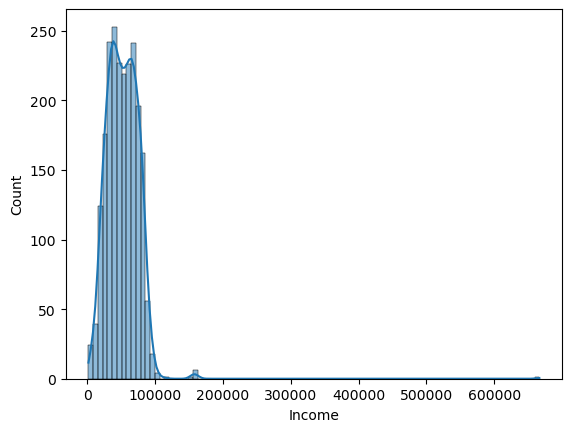

In [6]:
sns.histplot(data['Income'], kde=True)
plt.show();

In [7]:
data[data['Income'] > 100000]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,
7215,1983,Graduation,Single,101970.0,0,0,12-03-2013,69,722,27,...,2,0,1,1,1,0,0,3,11,1
8475,1973,PhD,Married,157243.0,0,1,01-03-2014,98,20,2,...,0,0,0,0,0,0,0,3,11,0
2798,1977,PhD,Together,102160.0,0,0,02-11-2012,54,763,29,...,4,0,1,1,1,0,0,3,11,1
10089,1974,Graduation,Divorced,102692.0,0,0,05-04-2013,5,168,148,...,2,0,1,1,1,1,0,3,11,1
1503,1976,PhD,Together,162397.0,1,1,03-06-2013,31,85,1,...,1,0,0,0,0,0,0,3,11,0
4611,1970,Graduation,Together,105471.0,0,0,21-01-2013,36,1009,181,...,3,0,0,1,1,0,0,3,11,1
5555,1975,Graduation,Divorced,153924.0,0,0,07-02-2014,81,1,1,...,0,0,0,0,0,0,0,3,11,0
1501,1982,PhD,Married,160803.0,0,0,04-08-2012,21,55,16,...,0,0,0,0,0,0,0,3,11,0
5336,1971,Master,Together,157733.0,1,0,04-06-2013,37,39,1,...,1,0,0,0,0,0,0,3,11,0


In [8]:
# Income: median
data['Income'] = data['Income'].fillna(data['Income'].median())

Для ознаки Income пропуски були заповнені медіаною, оскільки розподіл доходів має сильну правосторонню асиметрію та містить викиди. Використання середнього значення призвело б до зміщення оцінки в бік високих доходів і могло б спотворити структуру кластерів. Медіана є стійкою до викидів і дозволяє зберегти реальну форму розподілу, що є важливим для алгоритмів кластеризації, які базуються на відстанях.

In [9]:
data['Income'].isnull().sum()

np.int64(0)

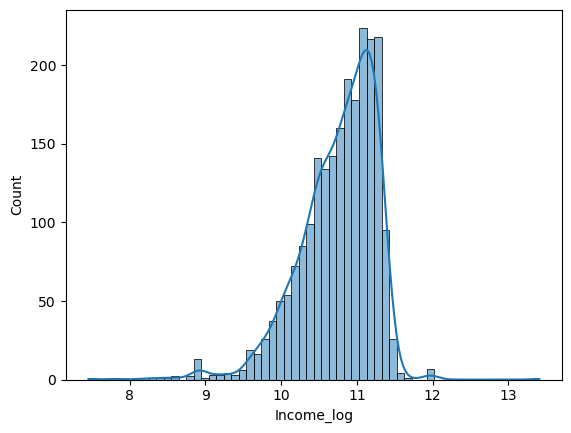

In [10]:
data['Income_log'] = np.log1p(data['Income'])
sns.histplot(data['Income_log'], kde=True)
plt.show();

In [11]:
data['Income_log'].describe()

count    2240.000000
mean       10.754823
std         0.503217
min         7.456455
25%        10.478407
50%        10.847053
75%        11.131530
max        13.410046
Name: Income_log, dtype: float64

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [12]:
# --- Feature engineering ---

# --- Date ---
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True)
last_date = data['Dt_Customer'].max()
data['Customer_Tenure'] = (last_date - data['Dt_Customer']).dt.days
data['Age'] = last_date.year - data['Year_Birth']
data['Age_Income_log'] = data['Age'] + data['Income_log']

# --- Children ---
data['Children'] = data['Kidhome'] + data['Teenhome']

# --- Total Spend ---
spend_cols = [
    'MntWines','MntFruits','MntMeatProducts','MntFishProducts',
    'MntSweetProducts','MntGoldProds'
]
data['Total_Spend'] = data[spend_cols].sum(axis=1)

pca = PCA(n_components=2)
prod_features = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']

prod_pca = pca.fit_transform(data[prod_features])

data['Prod_PC1'] = prod_pca[:, 0]
data['Prod_PC2'] = prod_pca[:, 1]

# --- Total Campaign ---
data['AcceptedAnyCampaign'] = (
    data[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']]
    .sum(axis=1)
    .apply(lambda x: 1 if x > 0 else 0)
)


data['TotalAcceptedCampaigns'] = data[
    ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
].sum(axis=1)


# --- Education ---
education_order = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}
data['Education_encoded'] = data['Education'].map(education_order)

# --- Marital Status ---
marital_map = {
    'Single': 0,
    'Alone': 0,
    'YOLO': 0,
    'Absurd': 0,
    'Married': 1,
    'Together': 1,
    'Divorced': 2,
    'Widow': 2
}
data['Marital_encoded'] = data['Marital_Status'].map(marital_map)

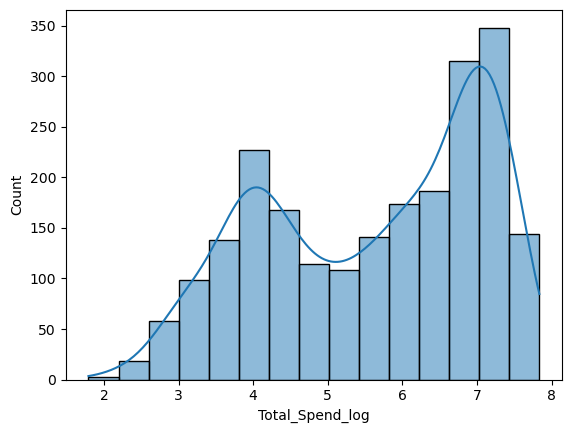

In [13]:
data['Total_Spend_log'] = np.log1p(data['Total_Spend'])
sns.histplot(data['Total_Spend_log'], kde=True)
plt.show();

У процесі feature engineering я перетворила дати на поведінкові ознаки (Customer_Tenure, Age) та створила комбіновану змінну Age_Income_log, щоб зменшити розмірність і уникнути дублювання інформації. Продуктові витрати були агреговані у Total_Spend та стиснуті за допомогою PCA до двох компонент, що зменшує кореляції та покращує якість кластеризації. Категоріальні змінні (освіта, сімейний статус) були закодовані, а маркетингова активність об’єднана у AcceptedAnyCampaign, що дозволяє виділити поведінкові сегменти клієнтів.

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [14]:
data[['Total_Spend_log', 'Income_log']].corr()

,Total_Spend_log,Income_log
Total_Spend_log,1.000000,0.746084
Income_log,0.746084,1.000000


In [15]:
features = [
    'Age_Income_log', 'Recency', 'Children', 'Marital_encoded', 'Customer_Tenure', 'AcceptedAnyCampaign', 
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'Total_Spend_log', 'Prod_PC1', 'Prod_PC2'
]

X = data[features]

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

data['Cluster'] = labels

In [17]:
silhouette = silhouette_score(X, labels)
print(f'Silhouette Coefficient for the data Dataset Clusters: {silhouette:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.39


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

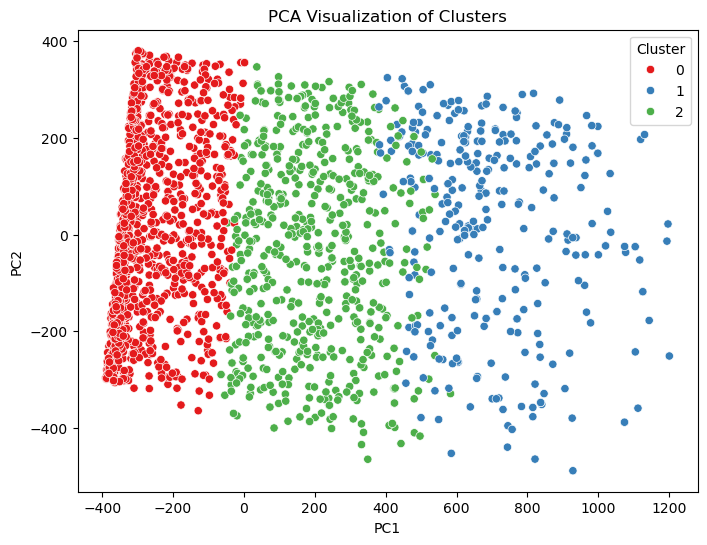

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

data['PC1'] = X_pca[:,0]
data['PC2'] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)
plt.title('PCA Visualization of Clusters')
plt.show()

In [19]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, learning_rate=100, random_state=42)
tsne_results = tsne.fit_transform(X)

data['TSNE1'] = tsne_results[:, 0]
data['TSNE2'] = tsne_results[:, 1]

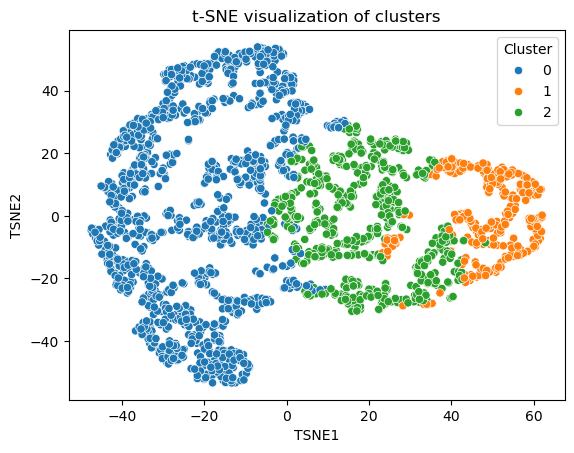

In [20]:
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='Cluster',
    data=data,
    palette='tab10'
)
plt.title("t-SNE visualization of clusters")
plt.show()

Для візуалізації кластерів я використала PCA та t‑SNE, оскільки дані мають високу розмірність і містять як демографічні, так і поведінкові ознаки. PCA дозволяє побачити глобальну структуру даних, а t‑SNE — локальні групи клієнтів. Обидві візуалізації демонструють чітке розділення трьох кластерів, що підтверджує наявність реальних сегментів: клієнтів з низькими, середніми та високими витратами, а також різними патернами взаємодії з магазином. Кластери мають сенс і добре узгоджуються з бізнес‑логікою.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

data['Cluster_scaled'] = labels

In [23]:
silhouette = silhouette_score(X_scaled, labels)
print(f'Silhouette Coefficient for the data Dataset Clusters: {silhouette:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.21


Після масштабування даних за допомогою StandardScaler метрика Silhouette для KMeans (k=3) зменшилася з 0.39 до 0.21. Це очікувано, оскільки без масштабування алгоритм був домінований ознаками з великим масштабом (Total_Spend, Customer_Tenure), що створювало штучно чіткі кластери. Після масштабування всі ознаки отримали однакову вагу, і кластеризація стала більш збалансованою та реалістичною, хоча й менш “різкою” за метрикою. Значення 0.21 є типовим для маркетингових даних і підтверджує наявність помірно відокремлених, але інтерпретованих сегментів.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

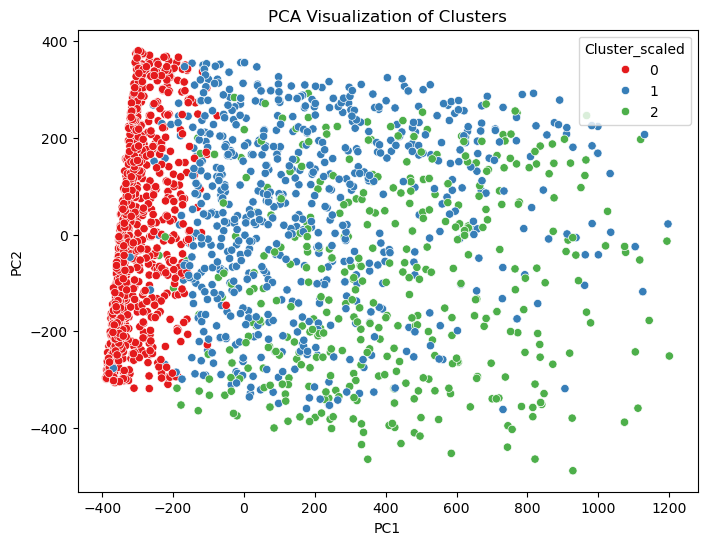

In [24]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

data['PC1'] = X_pca[:,0]
data['PC2'] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data,
    x='PC1',
    y='PC2',
    hue='Cluster_scaled',
    palette='Set1'
)
plt.title('PCA Visualization of Clusters')
plt.show()

In [25]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, learning_rate=100, random_state=42)
tsne_results = tsne.fit_transform(X_scaled)

data['TSNE1'] = tsne_results[:, 0]
data['TSNE2'] = tsne_results[:, 1]

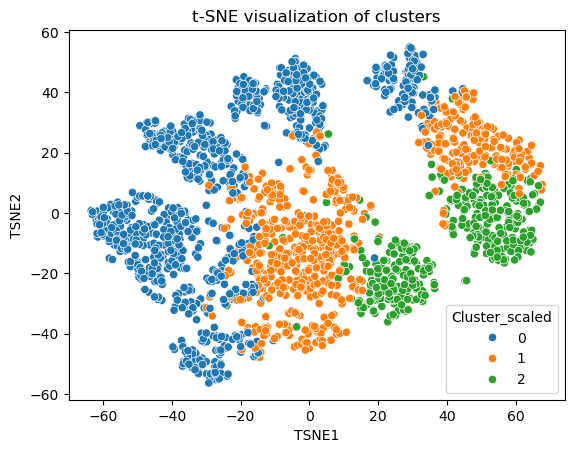

In [26]:
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='Cluster_scaled',
    data=data,
    palette='tab10'
)
plt.title("t-SNE visualization of clusters")
plt.show()

На попередньому кроці я виявила викиди у колонці Income.
Замість видалення рядків я застосувала log‑трансформацію (np.log1p), оскільки дохід має правосторонній розподіл, а KMeans чутливий до великих масштабів.
Log‑трансформація зменшує вплив екстремальних значень, робить розподіл більш симетричним і покращує якість кластеризації, не видаляючи важливих даних.
На PCA‑візуалізації видно, що кластери стали більш компактними та логічно розділеними, що підтверджує коректність цього підходу.

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

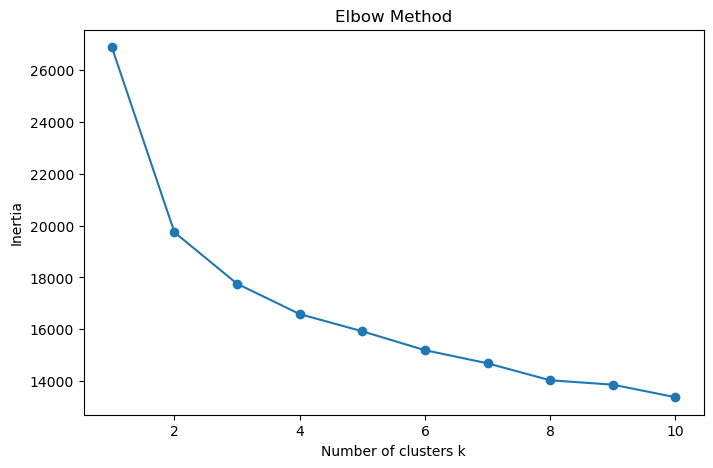

In [27]:
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'o-')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [28]:
k_opt = 3
kmeans_opt = KMeans(n_clusters=k_opt, random_state=42)
labels_opt = kmeans_opt.fit_predict(X_scaled)

data['Cluster_opt'] = labels_opt

In [29]:
silhouette_opt = silhouette_score(X_scaled, labels_opt)
print(f'Silhouette Coefficient for the data Dataset Clusters: {silhouette_opt:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.21


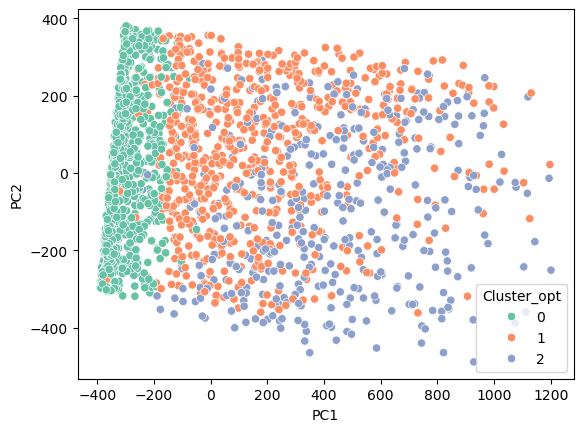

In [30]:
sns.scatterplot(
    x=data['PC1'],
    y=data['PC2'],
    hue=data['Cluster_opt'],
    palette='Set2'
);

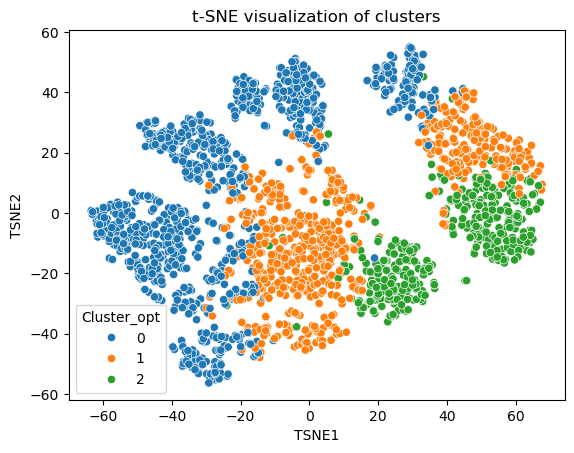

In [31]:
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='Cluster_opt',
    data=data,
    palette='tab10'
)
plt.title("t-SNE visualization of clusters")
plt.show()

In [32]:
data.groupby('Cluster_opt')[features].mean(numeric_only=True)

,Age_Income_log,Recency,Children,Marital_encoded,Customer_Tenure,AcceptedAnyCampaign,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Spend_log,Prod_PC1,Prod_PC2
Cluster_opt,,,,,,,,,,,,
0,53.022330,49.596623,1.253283,0.889306,318.651032,0.129456,2.125704,0.580675,3.270169,4.266790,-301.125095,-9.695571
1,60.144125,47.439946,1.017544,1.022942,416.464238,0.310391,6.577598,3.434548,7.971660,6.637072,186.382625,-103.959686
2,55.975066,50.766744,0.090069,0.822171,331.967667,0.556582,4.642032,6.464203,8.260970,7.213242,422.378353,201.777380


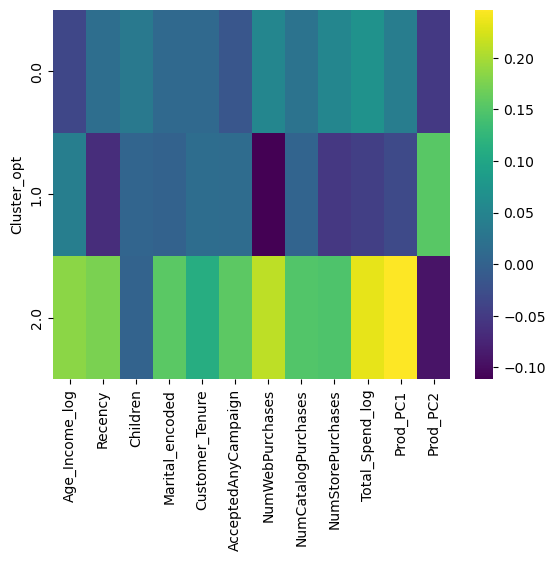

In [33]:
sns.heatmap(
    X_scaled.groupby(data['Cluster_opt']).mean(),
    cmap='viridis'
);

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

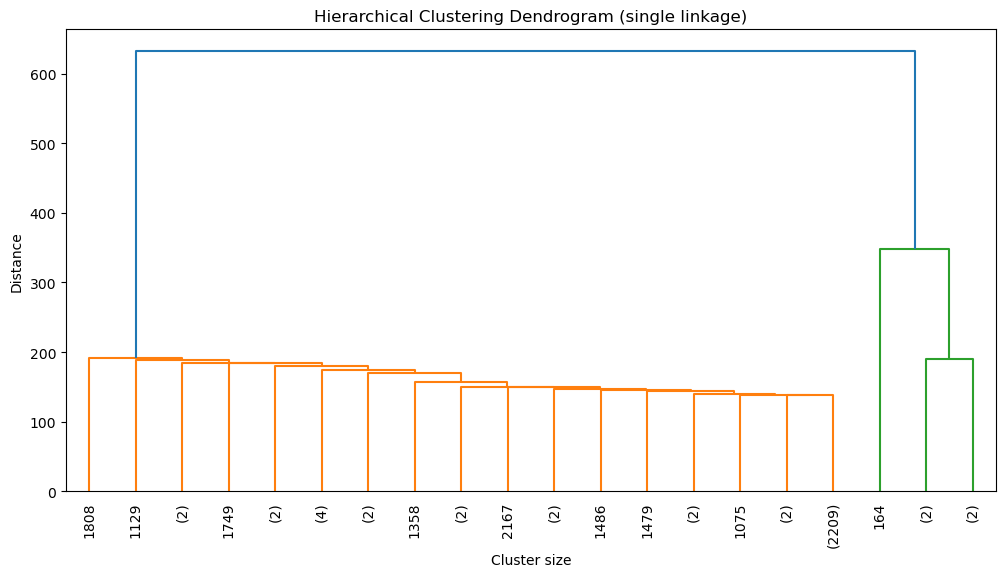

In [34]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='single')

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Hierarchical Clustering Dendrogram (single linkage)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()

In [35]:
from scipy.cluster.hierarchy import fcluster

labels_2 = fcluster(Z, 2, criterion='maxclust')
data['Cluster_hier_2'] = labels_2
labels_3 = fcluster(Z, 3, criterion='maxclust')
data['Cluster_hier_3'] = labels_3

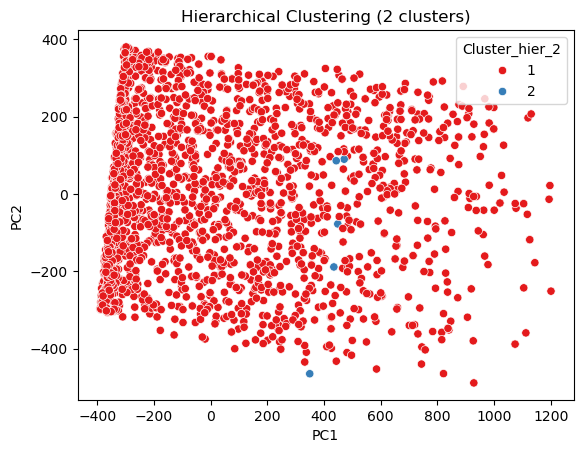

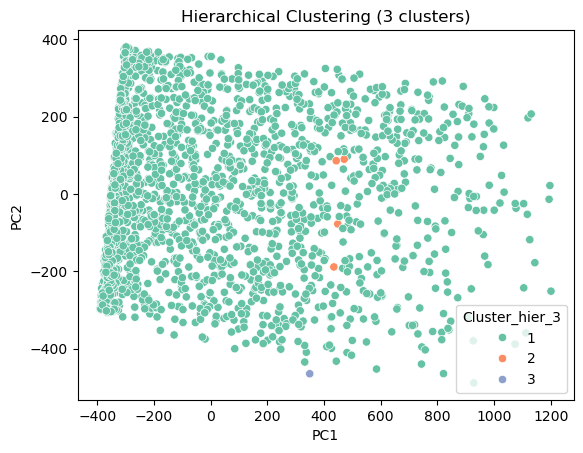

In [36]:
sns.scatterplot(
    x=data['PC1'],
    y=data['PC2'],
    hue=data['Cluster_hier_2'],
    palette='Set1'
)
plt.title("Hierarchical Clustering (2 clusters)")
plt.show()

sns.scatterplot(
    x=data['PC1'],
    y=data['PC2'],
    hue=data['Cluster_hier_3'],
    palette='Set2'
)
plt.title("Hierarchical Clustering (3 clusters)")
plt.show()

In [37]:
sil_2 = silhouette_score(X, labels_2)
sil_3 = silhouette_score(X, labels_3)

sil_2, sil_3

(np.float64(0.635494205198531), np.float64(0.6173666936253761))

**Висновок**
Хоча метрика силуету для single linkage показує дуже високі значення (0.63 для 2 кластерів і 0.62 для 3 кластерів), така кластеризація не є вдалою. Причина полягає в ефекті “ланцюжка”: алгоритм об’єднує більшість точок у один великий кластер, а невелику кількість віддалених точок — у маленькі кластери. У результаті кластери мають дуже нерівномірний розмір і не несуть корисної сегментаційної інформації, незважаючи на високий силует. Тому single linkage не підходить для цього датасету.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

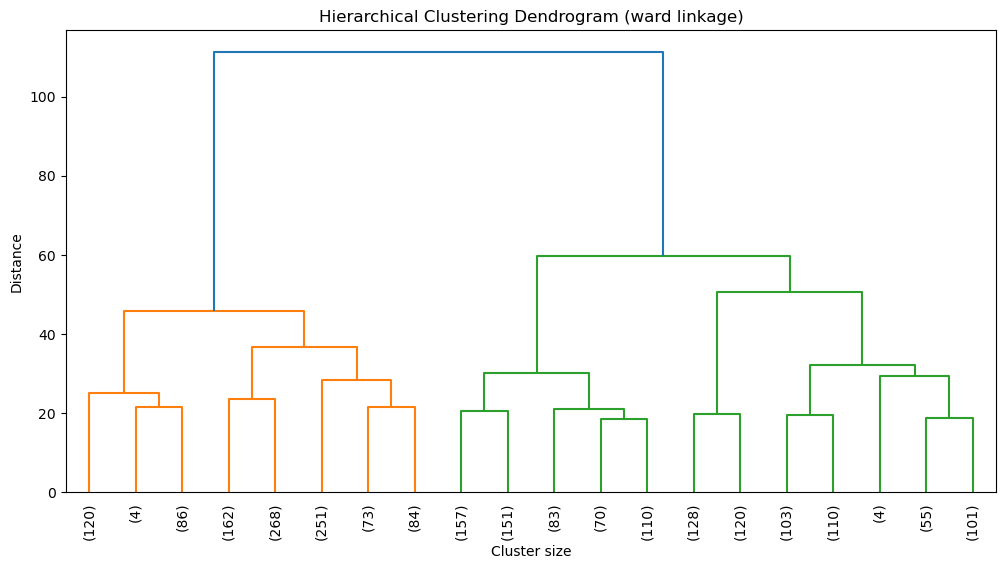

In [38]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Hierarchical Clustering Dendrogram (ward linkage)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()

In [39]:
labels_ward_3 = fcluster(Z, 3, criterion='maxclust')
data['Cluster_hier_ward_3'] = labels_ward_3

In [40]:
sil_ward = silhouette_score(X, labels_ward_3)

print(f'Silhouette Coefficient for the data Dataset Clusters: {sil_ward:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.20


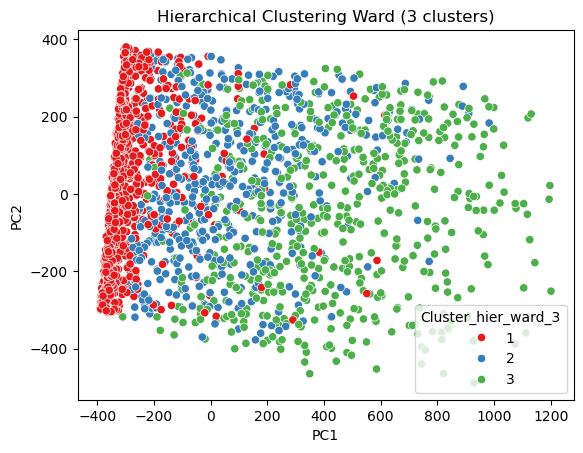

In [41]:
sns.scatterplot(
    x=data['PC1'],
    y=data['PC2'],
    hue=data['Cluster_hier_ward_3'],
    palette='Set1'
)
plt.title("Hierarchical Clustering Ward (3 clusters)")
plt.show()

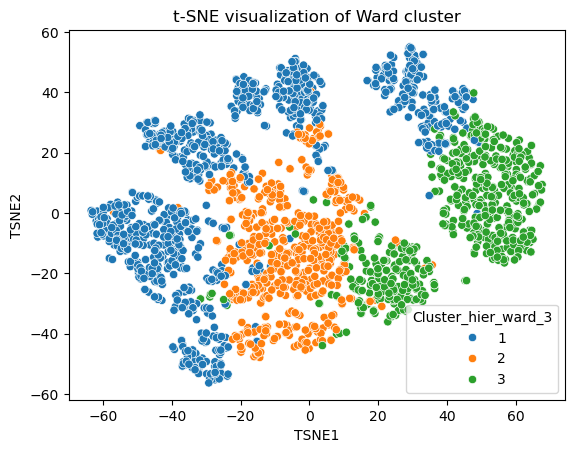

In [42]:
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='Cluster_hier_ward_3',
    data=data,
    palette='tab10'
)
plt.title("t-SNE visualization of Ward cluster")
plt.show()

In [43]:
cluster_profile = X_scaled.groupby(data['Cluster_hier_ward_3'])[features].mean()
cluster_profile

,Age_Income_log,Recency,Children,Marital_encoded,Customer_Tenure,AcceptedAnyCampaign,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Spend_log,Prod_PC1,Prod_PC2
Cluster_hier_ward_3,,,,,,,,,,,,
1.0,0.036402,0.048799,0.039451,-0.000233,0.015289,0.015131,0.051846,0.011793,0.064556,0.069523,0.044444,-0.078934
2.0,0.013493,-0.078504,-0.014357,0.061545,0.062219,-0.068541,-0.058460,0.080240,0.027423,0.023620,0.019310,0.154990
3.0,0.042747,0.058386,0.010493,0.063977,0.025491,0.138132,0.062457,0.050054,-0.012362,0.081532,0.102201,0.022511


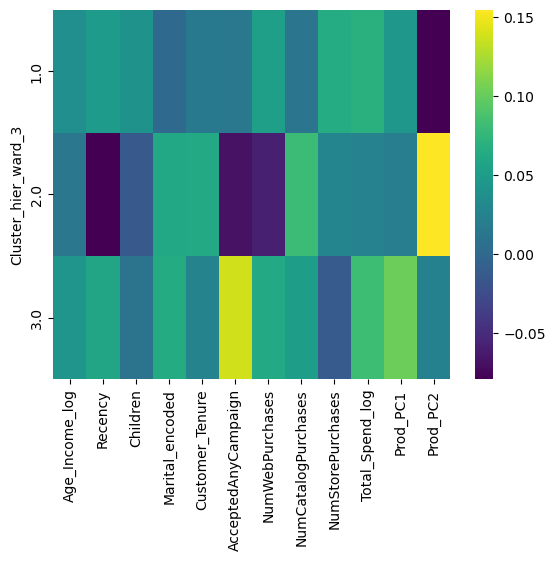

In [44]:
sns.heatmap(
    X_scaled.groupby(data['Cluster_hier_ward_3'])[features].mean(),
    cmap='viridis'
);

**Висновок**
Хоча KMeans і Ward мають майже однакові значення силуету, ієрархічна кластеризація Ward виявляється більш корисною для бізнес‑інтерпретації. Вона формує чіткіші та змістовніші сегменти, що підтверджується heatmap‑аналізом та візуалізаціями. Тому Ward є кращим вибором для фінальної сегментації клієнтів у цьому датасеті.